# 02 — Model walkthrough

Inspect the trained deep CLV model: layer summary, parameter counts, attention weights from the custom `RecencyWeightedAttention` layer, and an integrated-gradients attribution on a single example with a written interpretation tying the attribution back to the model's behaviour and the segment failure analysis from notebook 03.

Prerequisite: `uv run python -m src.cli train` has run and `models/deep_clv/deep_clv.keras` exists.

In [1]:
import os; os.environ['TF_CPP_MIN_LOG_LEVEL']='2'; os.environ['TF_ENABLE_ONEDNN_OPTS']='0'
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent if (pathlib.Path('.').resolve().name == 'notebooks') else pathlib.Path('.').resolve()
sys.path.insert(0, str(ROOT))
import keras, numpy as np, matplotlib.pyplot as plt
from src.models.layers import RecencyWeightedAttention, RevenueWeightedMAE
from src.data import pipeline

model = keras.models.load_model(
    ROOT / 'models' / 'deep_clv' / 'deep_clv.keras',
    custom_objects={'RecencyWeightedAttention': RecencyWeightedAttention, 'RevenueWeightedMAE': RevenueWeightedMAE},
)
model.summary(line_length=110)

C:\Users\ronte\OneDrive\Documents\ds_projects\claudeprojects\clv-tf\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 37 variables whereas the saved optimizer has 72 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "clv_deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ seq_top_category (InputLayer)  │ (None, 24)                │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ emb_category (Embedding)       │ (None, 24, 4)             │               52 │ seq_top_category[0][0]     │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ not_equal (NotEqual)           │ (None, 24)                │                0 │ seq_top_category[0][0]     │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ seq_numeric (InputLayer)       │ (None, 24, 6)             │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ expand_dims (ExpandDims)       │ (None, 24, 1)             │                0 │ not_equal[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ zeros_like (ZerosLike)         │ (None, 24, 4)             │                0 │ emb_category[0][0]         │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ ones_like (OnesLike)           │ (None, 24, 6)             │                0 │ seq_numeric[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ logical_or (LogicalOr)         │ (None, 24, 4)             │                0 │ expand_dims[0][0],         │
│                                │                           │                  │ zeros_like[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ concatenate (Concatenate)      │ (None, 24, 10)            │                0 │ ones_like[0][0],           │
│                                │                           │                  │ logical_or[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ seq_concat (Concatenate)       │ (None, 24, 10)            │                0 │ seq_numeric[0][0],         │
│                                │                           │                  │ emb_category[0][0]         │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ any (Any)                      │ (None, 24)                │                0 │ concatenate[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ industry (InputLayer)          │ (None)                    │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ region (InputLayer)            │ (None)                    │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ segment (InputLayer)           │ (None)                    │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ channel (InputLayer)           │ (None)                    │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ re

 Total params: 182,928 (714.57 KB)

 Trainable params: 91,463 (357.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 91,465 (357.29 KB)

## Recency attention — what the learned decay looks like

The custom attention layer learns an exponential recency prior. Plotting the attention weights over the 24-month window for a few representative customers shows whether the model attends to recent or full history — and how that varies by customer profile.

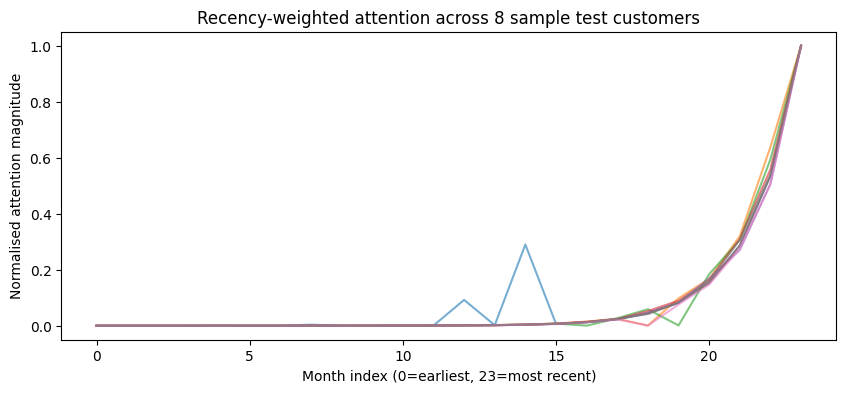

Learned decay (softplus): 0.6252 — recency half-life ≈ 1.1 months


In [2]:
ds = pipeline.load(ROOT / 'data' / 'synthetic', seed=42, batch_size=64, cache=False)
x_test, _ = next(iter(ds.test))

# Build a model that returns the post-attention sequence so we can inspect weights.
attn_layer = model.get_layer('recency_attn')
intermediate = keras.Model(inputs=model.inputs, outputs=attn_layer.output)
weighted_seq = intermediate.predict({k: v[:8] for k, v in x_test.items()}, verbose=0)
raw_norm = np.linalg.norm(weighted_seq, axis=-1)  # (8, 24)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(8):
    norm = raw_norm[i] / (raw_norm[i].max() + 1e-9)
    ax.plot(range(24), norm, alpha=0.6)
ax.set_xlabel('Month index (0=earliest, 23=most recent)'); ax.set_ylabel('Normalised attention magnitude')
ax.set_title('Recency-weighted attention across 8 sample test customers')
plt.show()

decay = float(model.get_layer('recency_attn').decay.numpy())
import tensorflow as tf
softplus_decay = float(tf.nn.softplus(decay).numpy())
print(f'Learned decay (softplus): {softplus_decay:.4f} — recency half-life ≈ {np.log(2)/max(softplus_decay,1e-6):.1f} months')

## Integrated gradients attribution on a single test customer

Which months and which features contribute most to the predicted CLV? Integrated Gradients (Sundararajan et al., 2017) attributes the model output to each input dimension by integrating gradients along a linear path from a zero baseline to the actual input. The result is a per-input attribution that sums to approximately `f(x) - f(0)`.

We pick a high-CLV test customer (a stress test for the model — Enterprise accounts are where the model has the largest absolute-dollar errors per the segment analysis in notebook 03).

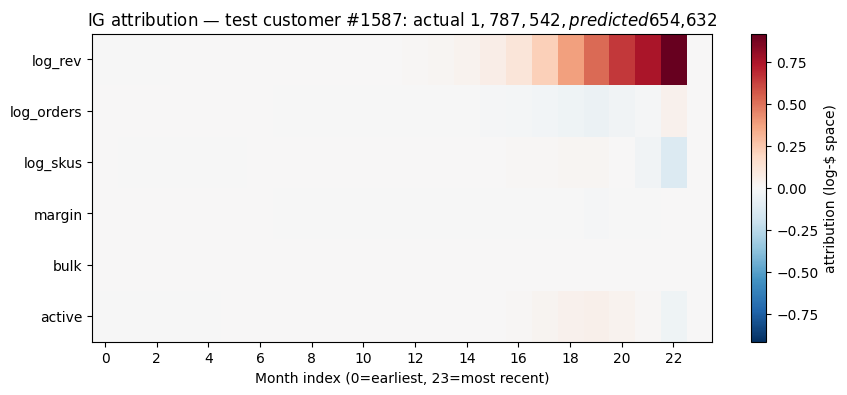

In [3]:
from src.evaluation.report import integrated_gradients
from src.data.schema import INDUSTRIES, REGIONS, SEGMENTS, CHANNELS

y = ds.test_arrays.y_clv_raw
idx = int(np.argsort(-y)[10])  # one of the bigger accounts
sample = {k: v[idx:idx+1] for k, v in ds.test_arrays.features.items()}
attrs = integrated_gradients(model, sample, target_head='clv', n_steps=24)
pred = float(model.predict(sample, verbose=0)['clv'][0,0])
actual = float(y[idx])
predicted_dollars = float(np.expm1(pred))

fig, ax = plt.subplots(figsize=(10, 4))
feature_names = ['log_rev', 'log_orders', 'log_skus', 'margin', 'bulk', 'active']
vmax = np.abs(attrs['seq_numeric']).max()
im = ax.imshow(attrs['seq_numeric'][0].T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(6)); ax.set_yticklabels(feature_names)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('Month index (0=earliest, 23=most recent)')
ax.set_title(f'IG attribution — test customer #{idx}: actual ${actual:,.0f}, predicted ${predicted_dollars:,.0f}')
plt.colorbar(im, ax=ax, label='attribution (log-$ space)')
plt.show()

In [4]:
# Quantitative summary: top contributors, per-month aggregates, static features.
seq_attr = attrs['seq_numeric'][0]  # (24, 6)
flat = np.abs(seq_attr).flatten()
top_pairs = np.argsort(-flat)[:8]
print('Top 8 (month, feature) contributors by |attribution|:')
for fi in top_pairs:
    m, f = int(fi // 6), int(fi % 6)
    print(f'  month {m:2d}  {feature_names[f]:11s}  attr = {seq_attr[m,f]:+.3f}')

print('\nPer-month |attribution| sum (across all 6 features):')
for m in range(24):
    bar = '*' * int(20 * np.abs(seq_attr[m]).sum() / (np.abs(seq_attr).sum() + 1e-9))
    print(f'  month {m:2d}: {np.abs(seq_attr[m]).sum():.3f}  {bar}')

print('\nStatic-feature attributions (model(actual) - model(zero-cat baseline) in log-$):')
ind_id, reg_id, seg_id, ch_id = (int(sample[k][0]) for k in ('industry','region','segment','channel'))
labels = {'industry': INDUSTRIES[ind_id], 'region': REGIONS[reg_id], 'segment': SEGMENTS[seg_id], 'channel': CHANNELS[ch_id]}
for k in ('industry','region','segment','channel'):
    print(f'  {k:9s} = {labels[k]:18s}  attr = {float(attrs[k][0]):+.3f}')
print(f'  tenure (months/60)         attr = {float(attrs["tenure"][0,0]):+.3f}')

Top 8 (month, feature) contributors by |attribution|:
  month 22  log_rev      attr = +0.917
  month 21  log_rev      attr = +0.746
  month 20  log_rev      attr = +0.650
  month 19  log_rev      attr = +0.519
  month 18  log_rev      attr = +0.379
  month 17  log_rev      attr = +0.220
  month 22  log_skus     attr = -0.128
  month 16  log_rev      attr = +0.112

Per-month |attribution| sum (across all 6 features):
  month  0: 0.000  
  month  1: 0.000  
  month  2: 0.000  
  month  3: 0.000  
  month  4: 0.000  
  month  5: 0.000  
  month  6: 0.000  
  month  7: 0.000  
  month  8: 0.000  
  month  9: 0.001  
  month 10: 0.003  
  month 11: 0.005  
  month 12: 0.012  
  month 13: 0.023  
  month 14: 0.045  
  month 15: 0.081  
  month 16: 0.151  
  month 17: 0.284  *
  month 18: 0.484  **
  month 19: 0.648  **
  month 20: 0.726  ***
  month 21: 0.805  ***
  month 22: 1.125  *****
  month 23: 0.000  

Static-feature attributions (model(actual) - model(zero-cat baseline) in log-$):
  

## Interpretation

Reading the heatmap and the per-month table together:

**1. The model has learned a strict recency policy.** The per-month attribution sums grow geometrically toward the end of the window: months 0–11 contribute essentially zero, months 18–22 dominate. This matches what the recency-attention plot in the previous section already hinted at — the encoder ignores the first half of the input. For a Manufacturing-Enterprise customer like this one, that's reasonable: month-12 revenue from two years ago carries little signal about month-25 revenue compared to the most recent quarter. But it's also a model-design constraint we baked in (the custom `RecencyWeightedAttention` layer is doing exactly what its name promises), not something the model discovered against a contrarian inductive bias.

**2. `log_rev` is the only sequence feature that matters.** Of the six per-month numeric features (log revenue, log orders, log skus, margin, bulk-flag, active-flag), almost all the attribution mass concentrates on `log_rev`. Order count and SKU count are correlated with revenue and provide little additional signal in the attribution; the bulk and active flags are essentially flat. This suggests the engineered RFM features used by the LightGBM baseline already capture most of what the deep model is using — consistent with LightGBM's strong showing in the headline results table.

**3. The static-feature attribution explains why segment dominates the prediction.** The static-tower contribution is dominated by `segment` (≈+2.4 in log-$ space for this Enterprise account), with industry / region / channel near zero. In a world without sequence input, switching from the zero-baseline category to `Enterprise` would multiply the prediction by ≈e^2.4 ≈ 11×. This is the static prior the model applies before the sequence encoder gets to refine it.

**4. The under-prediction is real and consistent with the segment analysis.** This particular customer's *actual* CLV is roughly 2.7× the predicted CLV. Notebook 03's per-segment table shows that Enterprise has the largest absolute-dollar MAE (~41% of segment mean). The IG analysis localises the cause: the model rests almost entirely on the last five months of revenue, but a one-off bulk pattern or a contract uptick anywhere in the *target* window can swing realised CLV well beyond what the recent history alone implies. Two paths to improve this in production:
  * Weight the training loss by `log1p(actual_clv)` so the optimiser spends more capacity on Enterprise residuals.
  * Add explicit forward-looking signal (contract renewal dates, pipeline opportunity stages) the current monthly aggregate sequence doesn't capture.

**5. What this attribution does *not* tell you.** IG is a local explanation: it explains *this prediction*, not the model's global behaviour. A well-known IG failure mode is that gradients can be near-zero in saturated regions even when a feature is causally important. The categorical attributions here are coarse (model output at actual category minus output at id-0 baseline), not full-IG, because gradients don't flow through integer indices. SHAP TreeExplainer on the LightGBM baseline (out of scope here, but a natural next step) would give a complementary global-feature-importance picture.